# Timestomping Detection Tool - View Results

This notebook:
- Loads detection results from Notebook 03
- Validates against ground truth (if available)
- Calculates performance metrics
- Generates visualizations
- Creates comprehensive summary report


## Cell 1: Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Paths - UPDATE THESE FOR YOUR DATASET
OUTPUT_DIR = '/Users/soni/Github/Digital-Detectives_Thesis/data/processed/Prototype Tool Output/LW'
SUSPICIOUS_CSV_PATH = '/Users/soni/Github/Digital-Detectives_Thesis/data/Lone Wolf/LW-Suspicious.csv'  # Set to None if not available

# Configuration
CONFIDENCE_THRESHOLD = 70  # Must match threshold from Notebook 03

print(f"Output Directory: {OUTPUT_DIR}")
print(f"Ground Truth CSV: {SUSPICIOUS_CSV_PATH if SUSPICIOUS_CSV_PATH else 'Not available (production mode)'}")
print(f"Confidence Threshold: {CONFIDENCE_THRESHOLD}%")


Output Directory: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Prototype Tool Output/LW
Ground Truth CSV: /Users/soni/Github/Digital-Detectives_Thesis/data/Lone Wolf/LW-Suspicious.csv
Confidence Threshold: 70%


## Cell 2: Load Results


In [2]:
print("="*80)
print("LOADING DETECTION RESULTS")
print("="*80)

# Load flagged files
flagged_df = pd.read_csv(f'{OUTPUT_DIR}/flagged_files.csv')
print(f"\nLoaded {len(flagged_df)} flagged files")

# Load all predictions
predictions_df = pd.read_csv(f'{OUTPUT_DIR}/predictions.csv')
print(f"Loaded {len(predictions_df)} total predictions")

# Load ground truth if available
ground_truth_df = None
if SUSPICIOUS_CSV_PATH and os.path.exists(SUSPICIOUS_CSV_PATH):
    ground_truth_df = pd.read_csv(SUSPICIOUS_CSV_PATH)
    print(f"Loaded {len(ground_truth_df)} ground truth records")
else:
    print("No ground truth file provided (production mode)")

print(f"\nFlagged files columns: {len(flagged_df.columns)}")
print(f"Sample columns: {list(flagged_df.columns[:10])}")


LOADING DETECTION RESULTS

Loaded 24 flagged files
Loaded 7420 total predictions
Loaded 15 ground truth records

Flagged files columns: 33
Sample columns: ['filename', 'full_path', 'lf_lsn', 'usn_usn', 'confidence_pct', 'usn_event_time', 'lf_event', 'lf_detail', 'usn_event_info', 'zero_in_nanoseconds']


## Cell 3: Ground Truth Validation (File-Level)


In [3]:
print("="*80)
print("GROUND TRUTH VALIDATION (FILE-LEVEL)")
print("="*80)

if ground_truth_df is not None:
    # Extract unique filenames from ground truth
    gt_files = set()
    for _, row in ground_truth_df.iterrows():
        detail = str(row.get('detail', ''))
        
        # Extract filename from detail field
        if 'timestamp of ' in detail.lower():
            # Pattern: "[Suspicious] The timestamp of FILENAME may have been manipulated"
            parts = detail.split('timestamp of ')
            if len(parts) > 1:
                filename = parts[1].split('"')[0].strip()
                if filename:
                    gt_files.add(filename.lower())
        elif 'has been deleted' in detail.lower():
            # Pattern: "FILENAME has been deleted"
            filename = detail.split('"')[0].strip()
            if filename:
                gt_files.add(filename.lower())
    
    print(f"\nGround Truth Files: {len(gt_files)}")
    print(f"Files: {sorted(gt_files)}")
    
    # Extract detected filenames
    detected_files = set(flagged_df['filename'].str.lower())
    
    print(f"\nDetected Files: {len(detected_files)}")
    
    # Calculate file-level metrics
    true_positives = gt_files.intersection(detected_files)
    false_negatives = gt_files - detected_files
    false_positives = detected_files - gt_files
    
    recall = len(true_positives) / len(gt_files) if len(gt_files) > 0 else 0
    precision = len(true_positives) / len(detected_files) if len(detected_files) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print("\n" + "="*80)
    print("FILE-LEVEL PERFORMANCE METRICS")
    print("="*80)
    print(f"True Positives:  {len(true_positives):>3} / {len(gt_files):<3} ({recall*100:.1f}%)")
    print(f"False Negatives: {len(false_negatives):>3} / {len(gt_files):<3}")
    print(f"False Positives: {len(false_positives):>3} / {len(detected_files):<3}")
    print()
    print(f"Recall:    {recall*100:>6.2f}%  (TP / Known Timestomped)")
    print(f"Precision: {precision*100:>6.2f}%  (TP / Total Flagged)")
    print(f"F1 Score:  {f1*100:>6.2f}%")
    
    if len(true_positives) > 0:
        print(f"\nDETECTED ({len(true_positives)}):")
        for filename in sorted(true_positives):
            conf = flagged_df[flagged_df['filename'].str.lower() == filename]['confidence_pct'].values
            if len(conf) > 0:
                print(f"  - {filename:<30} ({conf[0]:.1f}% confidence)")
    
    if len(false_negatives) > 0:
        print(f"\nMISSED ({len(false_negatives)}):")
        for filename in sorted(false_negatives):
            print(f"  - {filename}")
    
    if len(false_positives) > 0:
        print(f"\nADDITIONAL DETECTIONS ({len(false_positives)}):")
        for filename in sorted(false_positives):
            conf = flagged_df[flagged_df['filename'].str.lower() == filename]['confidence_pct'].values
            if len(conf) > 0:
                print(f"  - {filename:<50} ({conf[0]:.1f}% confidence)")
        print("\nNote: These may be true positives not in ground truth or false positives requiring manual investigation.")
    
    # Store metrics for report
    metrics = {
        'true_positives': len(true_positives),
        'false_negatives': len(false_negatives),
        'false_positives': len(false_positives),
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'ground_truth_count': len(gt_files),
        'detected_count': len(detected_files)
    }
else:
    print("\nNo ground truth available - running in production mode.")
    print(f"Total flagged files: {len(flagged_df)}")
    
    metrics = {
        'detected_count': len(flagged_df),
        'ground_truth_count': None,
        'recall': None,
        'precision': None,
        'f1': None
    }


GROUND TRUTH VALIDATION (FILE-LEVEL)

Ground Truth Files: 13
Files: ['airport information.docx', 'bladeofgrass.jpg', 'cubadearmed.jpg', 'darkwolf.png', 'deathtoll.jpg', 'demlogic.jpg', 'get started with dropbox (deleted 72959d95ea583613843b11151d26591a).pdf', 'holdmytidepod.jpg', 'huckleberry.png', 'mytiredhead.jpg', 'planning.docx', 'redguns.jpg', 'sheep.jpg']

Detected Files: 24

FILE-LEVEL PERFORMANCE METRICS
True Positives:   12 / 13  (92.3%)
False Negatives:   1 / 13 
False Positives:  12 / 24 

Recall:     92.31%  (TP / Known Timestomped)
Precision:  50.00%  (TP / Total Flagged)
F1 Score:   64.86%

DETECTED (12):
  - airport information.docx       (98.0% confidence)
  - bladeofgrass.jpg               (98.0% confidence)
  - cubadearmed.jpg                (99.4% confidence)
  - darkwolf.png                   (98.9% confidence)
  - deathtoll.jpg                  (99.2% confidence)
  - demlogic.jpg                   (98.9% confidence)
  - holdmytidepod.jpg              (98.0% confide

## Cell 4: Confidence Distribution Analysis

In [4]:
print("="*80)
print("CONFIDENCE DISTRIBUTION ANALYSIS")
print("="*80)

# Overall statistics
print(f"\nTotal Files Analyzed: {len(predictions_df)}")
print(f"Files Flagged (>={CONFIDENCE_THRESHOLD}%): {len(flagged_df)}")
print(f"Files Not Flagged (<{CONFIDENCE_THRESHOLD}%): {len(predictions_df) - len(flagged_df)}")

# Confidence statistics for flagged files
print(f"\nFlagged Files Confidence Stats:")
print(f"  Mean:   {flagged_df['confidence_pct'].mean():.2f}%")
print(f"  Median: {flagged_df['confidence_pct'].median():.2f}%")
print(f"  Min:    {flagged_df['confidence_pct'].min():.2f}%")
print(f"  Max:    {flagged_df['confidence_pct'].max():.2f}%")
print(f"  Std:    {flagged_df['confidence_pct'].std():.2f}%")

# Confidence brackets
print(f"\nConfidence Distribution:")
brackets = [
    (90, 100, "Very High"),
    (80, 90, "High"),
    (70, 80, "Medium"),
    (60, 70, "Low"),
    (0, 60, "Very Low")
]

for min_conf, max_conf, label in brackets:
    count = len(flagged_df[(flagged_df['confidence_pct'] >= min_conf) & 
                           (flagged_df['confidence_pct'] < max_conf)])
    if max_conf == 100:
        count = len(flagged_df[flagged_df['confidence_pct'] >= min_conf])
    pct = (count / len(flagged_df) * 100) if len(flagged_df) > 0 else 0
    print(f"  {label:>10} ({min_conf:>3}-{max_conf:>3}%): {count:>3} files ({pct:>5.1f}%)")


CONFIDENCE DISTRIBUTION ANALYSIS

Total Files Analyzed: 7420
Files Flagged (>=70%): 24
Files Not Flagged (<70%): 7396

Flagged Files Confidence Stats:
  Mean:   99.13%
  Median: 99.29%
  Min:    98.02%
  Max:    99.84%
  Std:    0.65%

Confidence Distribution:
   Very High ( 90-100%):  24 files (100.0%)
        High ( 80- 90%):   0 files (  0.0%)
      Medium ( 70- 80%):   0 files (  0.0%)
         Low ( 60- 70%):   0 files (  0.0%)
    Very Low (  0- 60%):   0 files (  0.0%)


## Cell 5: Cross-Artifact Validation Analysis


In [5]:
print("="*80)
print("CROSS-ARTIFACT VALIDATION ANALYSIS")
print("="*80)

# Check which columns are available
has_cross_artifact = 'cross_artifact_detected' in flagged_df.columns
has_logfile = 'has_logfile_evidence' in flagged_df.columns
has_usnjrnl = 'has_usnjrnl_evidence' in flagged_df.columns

if has_cross_artifact:
    cross_validated = flagged_df[flagged_df['cross_artifact_detected'] == True]
    print(f"\nCross-Artifact Validated: {len(cross_validated)} / {len(flagged_df)} ({len(cross_validated)/len(flagged_df)*100:.1f}%)")
    print("  -> Evidence from BOTH LogFile AND UsnJrnl (highest confidence)")
    
if has_logfile and has_usnjrnl:
    logfile_only = flagged_df[(flagged_df['has_logfile_evidence'] == True) & 
                               (flagged_df['has_usnjrnl_evidence'] == False)]
    usnjrnl_only = flagged_df[(flagged_df['has_logfile_evidence'] == False) & 
                               (flagged_df['has_usnjrnl_evidence'] == True)]
    
    print(f"\nLogFile Only: {len(logfile_only)} / {len(flagged_df)} ({len(logfile_only)/len(flagged_df)*100:.1f}%)")
    print(f"UsnJrnl Only: {len(usnjrnl_only)} / {len(flagged_df)} ({len(usnjrnl_only)/len(flagged_df)*100:.1f}%)")

# Check for forensic indicators
print("\nForensic Indicators:")
if 'zero_in_nanoseconds' in flagged_df.columns:
    zero_nano = flagged_df[flagged_df['zero_in_nanoseconds'] == True]
    print(f"  Zero Nanoseconds:    {len(zero_nano):>3} / {len(flagged_df):<3} ({len(zero_nano)/len(flagged_df)*100:.1f}%)")

if 'time_reversal_event' in flagged_df.columns:
    time_reversal = flagged_df[flagged_df['time_reversal_event'] == True]
    print(f"  Time Reversal Event: {len(time_reversal):>3} / {len(flagged_df):<3} ({len(time_reversal)/len(flagged_df)*100:.1f}%)")

if 'basic_info_changed' in flagged_df.columns:
    basic_info = flagged_df[flagged_df['basic_info_changed'] == True]
    print(f"  Basic_Info_Changed:  {len(basic_info):>3} / {len(flagged_df):<3} ({len(basic_info)/len(flagged_df)*100:.1f}%)")


CROSS-ARTIFACT VALIDATION ANALYSIS

Cross-Artifact Validated: 24 / 24 (100.0%)
  -> Evidence from BOTH LogFile AND UsnJrnl (highest confidence)

LogFile Only: 0 / 24 (0.0%)
UsnJrnl Only: 0 / 24 (0.0%)

Forensic Indicators:
  Zero Nanoseconds:     19 / 24  (79.2%)
  Time Reversal Event:  24 / 24  (100.0%)
  Basic_Info_Changed:   24 / 24  (100.0%)


## Cell 6: Forensic Evidence Examples


In [6]:
print("="*80)
print("SAMPLE FORENSIC EVIDENCE")
print("="*80)

# Show top 3 detections
top_detections = flagged_df.nlargest(3, 'confidence_pct')

for idx, row in top_detections.iterrows():
    print("\n" + "="*80)
    print(f"FILE: {row.get('filename', 'N/A')}")
    print("="*80)
    print(f"Location:    {row.get('full_path', 'N/A')}")
    print(f"Confidence:  {row.get('confidence_pct', 0):.2f}%")
    
    # Forensic identifiers
    if pd.notna(row.get('lf_lsn')):
        print(f"LogFile LSN: {int(row['lf_lsn'])}")
    if pd.notna(row.get('usn_usn')):
        print(f"UsnJrnl USN: {int(row['usn_usn'])}")
    
    # Timeline
    print("\nTIMELINE:")
    if pd.notna(row.get('usn_event_time')):
        print(f"  UsnJrnl Event: {row['usn_event_time']}")
    if pd.notna(row.get('lf_event_time')):
        print(f"  LogFile Event: {row['lf_event_time']}")
    
    # Manipulation details
    print("\nMANIPULATION DETAILS:")
    if pd.notna(row.get('lf_event')):
        print(f"  Event Type:    {row['lf_event']}")
    if pd.notna(row.get('lf_detail')):
        detail = str(row['lf_detail'])
        if len(detail) > 200:
            detail = detail[:200] + "..."
        print(f"  Details:       {detail}")
    if pd.notna(row.get('usn_event_info')):
        print(f"  USN EventInfo: {row['usn_event_info']}")
    
    # Forensic indicators
    print("\nFORENSIC INDICATORS:")
    indicators = []
    if row.get('zero_in_nanoseconds') == True:
        indicators.append("Zero Nanoseconds")
    if row.get('time_reversal_event') == True:
        indicators.append("Time Reversal")
    if row.get('basic_info_changed') == True:
        indicators.append("Basic_Info_Changed")
    if row.get('cross_artifact_detected') == True:
        indicators.append("Cross-Artifact Validated")
    
    if indicators:
        for ind in indicators:
            print(f"  [X] {ind}")
    else:
        print("  (No indicators available in output)")


SAMPLE FORENSIC EVIDENCE

FILE: appraiser.sdb
Location:    \Windows\appcompat\appraiser\AltData\appraiser.sdb
Confidence:  99.84%
LogFile LSN: 1546631961
UsnJrnl USN: 247474288

TIMELINE:
  UsnJrnl Event: 4/6/18 15:23

MANIPULATION DETAILS:
  Event Type:    Time Reversal Event
  Details:       ModifiedTime : 2018-04-06 15:23:03 -> 2018-03-23 04:22:26(Zero in 100-nanoseconds)
  USN EventInfo: File_Created / Basic_Info_Changed / Data_Added / File_Closed

FORENSIC INDICATORS:
  [X] Zero Nanoseconds
  [X] Time Reversal
  [X] Basic_Info_Changed
  [X] Cross-Artifact Validated

FILE: Set9A38.tmp
Location:    \Users\jcloudy\AppData\Local\Temp\Set9A38.tmp
Confidence:  99.83%
LogFile LSN: 1547476312
UsnJrnl USN: 247686728

TIMELINE:
  UsnJrnl Event: 4/6/18 15:34

MANIPULATION DETAILS:
  Event Type:    Time Reversal Event
  Details:       ModifiedTime : 2018-04-06 15:34:31 -> 2018-04-06 15:24:33
  USN EventInfo: File_Created / Basic_Info_Changed / File_Closed

FORENSIC INDICATORS:
  [X] Time Reve

## Cell 7: Visualization - Confidence Distribution


Generating confidence distribution visualization...



/var/folders/sr/rwz9byz534105m7jk4k_sl0c0000gn/T/ipykernel_83573/1922520819.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([flagged_df['confidence_pct']], labels=['Flagged Files'], vert=True)


Saved: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Prototype Tool Output/LW/confidence_distribution.png


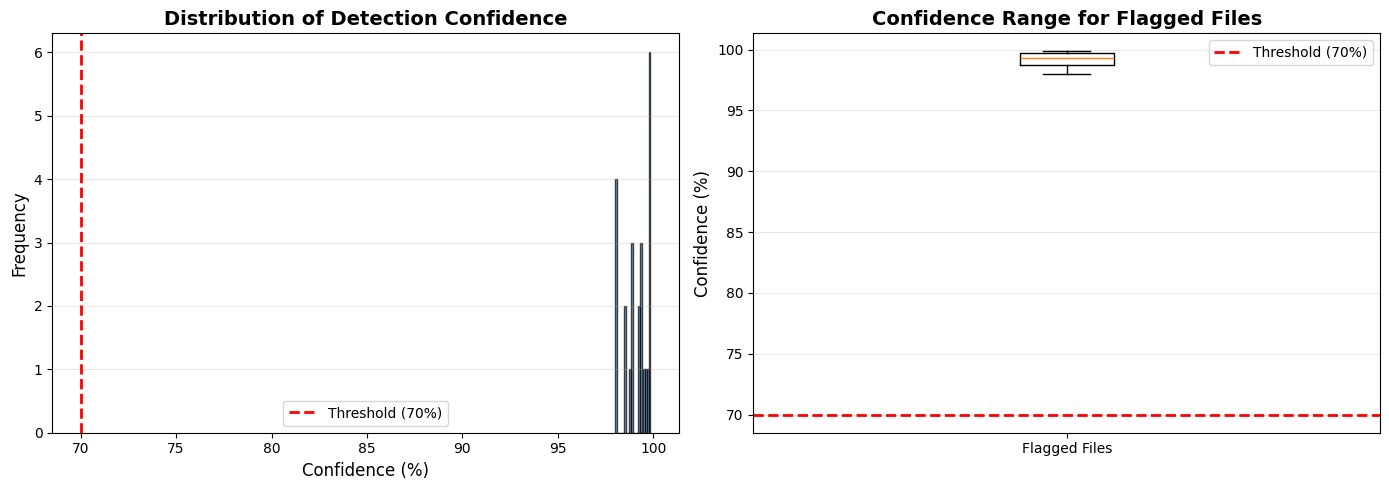

In [7]:
print("Generating confidence distribution visualization...\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(flagged_df['confidence_pct'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({CONFIDENCE_THRESHOLD}%)')
axes[0].set_xlabel('Confidence (%)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Detection Confidence', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot([flagged_df['confidence_pct']], labels=['Flagged Files'], vert=True)
axes[1].axhline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({CONFIDENCE_THRESHOLD}%)')
axes[1].set_ylabel('Confidence (%)', fontsize=12)
axes[1].set_title('Confidence Range for Flagged Files', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confidence_distribution.png', dpi=150, bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/confidence_distribution.png")
plt.show()


## Cell 8: Visualization - Detection Breakdown


Generating detection breakdown visualization...

Saved: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Prototype Tool Output/LW/detection_breakdown.png


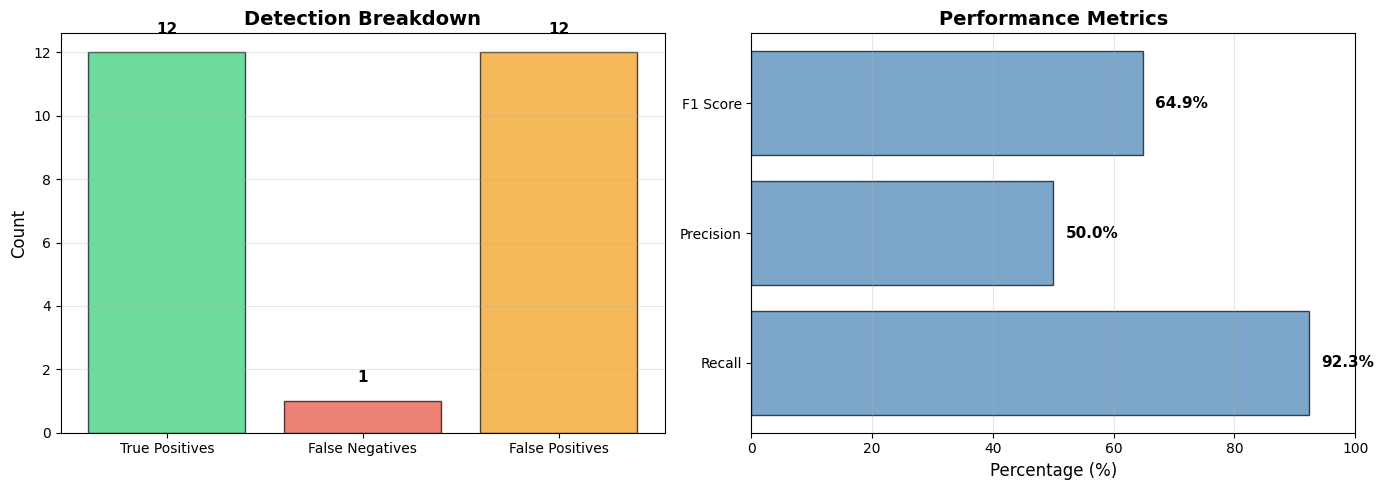

In [8]:
if ground_truth_df is not None and metrics['ground_truth_count'] is not None:
    print("Generating detection breakdown visualization...\n")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion matrix-style visualization
    categories = ['True Positives', 'False Negatives', 'False Positives']
    values = [metrics['true_positives'], metrics['false_negatives'], metrics['false_positives']]
    colors = ['#2ecc71', '#e74c3c', '#f39c12']
    
    axes[0].bar(categories, values, color=colors, edgecolor='black', alpha=0.7)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Detection Breakdown', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (cat, val) in enumerate(zip(categories, values)):
        axes[0].text(i, val + 0.5, str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Performance metrics
    metric_names = ['Recall', 'Precision', 'F1 Score']
    metric_values = [metrics['recall'] * 100, metrics['precision'] * 100, metrics['f1'] * 100]
    
    bars = axes[1].barh(metric_names, metric_values, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Percentage (%)', fontsize=12)
    axes[1].set_title('Performance Metrics', fontsize=14, fontweight='bold')
    axes[1].set_xlim(0, 100)
    axes[1].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, metric_values):
        axes[1].text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                     va='center', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/detection_breakdown.png', dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_DIR}/detection_breakdown.png")
    plt.show()
else:
    print("Skipping detection breakdown - no ground truth available.")


## Cell 9: Generate Summary Report


In [9]:
print("="*80)
print("GENERATING SUMMARY REPORT")
print("="*80)

report_lines = []
report_lines.append("="*80)
report_lines.append("NTFS TIMESTOMPING DETECTION - SUMMARY REPORT")
report_lines.append("="*80)
report_lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append(f"Model: LightGBM (Oh et al. 2024 Implementation)")
report_lines.append(f"Output Directory: {OUTPUT_DIR}")
report_lines.append("")

# Configuration
report_lines.append("CONFIGURATION")
report_lines.append("="*80)
report_lines.append(f"Confidence Threshold: {CONFIDENCE_THRESHOLD}%")
report_lines.append(f"Ground Truth Available: {'Yes' if ground_truth_df is not None else 'No (Production Mode)'}")
report_lines.append("")

# Detection Summary
report_lines.append("DETECTION SUMMARY")
report_lines.append("="*80)
report_lines.append(f"Total Files Analyzed:        {len(predictions_df):>6}")
report_lines.append(f"Files Flagged (>={CONFIDENCE_THRESHOLD}%):      {len(flagged_df):>6}")
report_lines.append(f"Flagged Rate:                {len(flagged_df)/len(predictions_df)*100:>6.2f}%")
report_lines.append("")

# Performance Metrics (if ground truth available)
if ground_truth_df is not None and metrics['ground_truth_count'] is not None:
    report_lines.append("VALIDATION AGAINST GROUND TRUTH (FILE-LEVEL)")
    report_lines.append("="*80)
    report_lines.append(f"Known Timestomped Files:     {metrics['ground_truth_count']:>6}")
    report_lines.append(f"True Positives:              {metrics['true_positives']:>6}")
    report_lines.append(f"False Negatives:             {metrics['false_negatives']:>6}")
    report_lines.append(f"False Positives:             {metrics['false_positives']:>6}")
    report_lines.append("")
    report_lines.append(f"Recall:                      {metrics['recall']*100:>6.2f}%  (TP / Known Timestomped)")
    report_lines.append(f"Precision:                   {metrics['precision']*100:>6.2f}%  (TP / Total Flagged)")
    report_lines.append(f"F1 Score:                    {metrics['f1']*100:>6.2f}%")
    report_lines.append("")
    
    if metrics['recall'] == 1.0:
        report_lines.append("PERFECT RECALL: All known timestomped files were detected!")
    elif metrics['recall'] >= 0.9:
        report_lines.append("EXCELLENT RECALL: >90% of timestomped files detected.")
    elif metrics['recall'] >= 0.7:
        report_lines.append("GOOD RECALL: 70-90% of timestomped files detected.")
    else:
        report_lines.append("LOW RECALL: <70% of timestomped files detected.")
    report_lines.append("")

# Confidence Statistics
report_lines.append("CONFIDENCE STATISTICS (FLAGGED FILES)")
report_lines.append("="*80)
report_lines.append(f"Mean:                        {flagged_df['confidence_pct'].mean():>6.2f}%")
report_lines.append(f"Median:                      {flagged_df['confidence_pct'].median():>6.2f}%")
report_lines.append(f"Min:                         {flagged_df['confidence_pct'].min():>6.2f}%")
report_lines.append(f"Max:                         {flagged_df['confidence_pct'].max():>6.2f}%")
report_lines.append(f"Std Dev:                     {flagged_df['confidence_pct'].std():>6.2f}%")
report_lines.append("")

# Confidence Distribution
report_lines.append("CONFIDENCE DISTRIBUTION")
report_lines.append("="*80)
for min_conf, max_conf, label in brackets:
    count = len(flagged_df[(flagged_df['confidence_pct'] >= min_conf) & 
                           (flagged_df['confidence_pct'] < max_conf)])
    if max_conf == 100:
        count = len(flagged_df[flagged_df['confidence_pct'] >= min_conf])
    pct = (count / len(flagged_df) * 100) if len(flagged_df) > 0 else 0
    report_lines.append(f"{label:>10} ({min_conf:>3}-{max_conf:>3}%):   {count:>4} files ({pct:>5.1f}%)")
report_lines.append("")

# Cross-Artifact Validation
if has_cross_artifact:
    report_lines.append("CROSS-ARTIFACT VALIDATION")
    report_lines.append("="*80)
    cross_count = len(flagged_df[flagged_df['cross_artifact_detected'] == True])
    report_lines.append(f"Cross-Validated:             {cross_count:>6} / {len(flagged_df):<6} ({cross_count/len(flagged_df)*100:.1f}%)")
    report_lines.append("  -> Evidence from BOTH LogFile AND UsnJrnl")
    report_lines.append("")

# Forensic Indicators
report_lines.append("FORENSIC INDICATORS (IN FLAGGED FILES)")
report_lines.append("="*80)
if 'zero_in_nanoseconds' in flagged_df.columns:
    count = len(flagged_df[flagged_df['zero_in_nanoseconds'] == True])
    report_lines.append(f"Zero Nanoseconds:            {count:>6} / {len(flagged_df):<6} ({count/len(flagged_df)*100:.1f}%)")
if 'time_reversal_event' in flagged_df.columns:
    count = len(flagged_df[flagged_df['time_reversal_event'] == True])
    report_lines.append(f"Time Reversal Event:         {count:>6} / {len(flagged_df):<6} ({count/len(flagged_df)*100:.1f}%)")
if 'basic_info_changed' in flagged_df.columns:
    count = len(flagged_df[flagged_df['basic_info_changed'] == True])
    report_lines.append(f"Basic_Info_Changed:          {count:>6} / {len(flagged_df):<6} ({count/len(flagged_df)*100:.1f}%)")
report_lines.append("")

# Output Files
report_lines.append("OUTPUT FILES")
report_lines.append("="*80)
report_lines.append(f"- flagged_files.csv              - {len(flagged_df)} files with full forensic details")
report_lines.append(f"- predictions.csv                - All {len(predictions_df)} files with confidence scores")
report_lines.append(f"- predictions_with_features.csv  - Flagged files with all {len(flagged_df.columns)} features")
report_lines.append(f"- confidence_distribution.png    - Visualization of confidence scores")
if ground_truth_df is not None:
    report_lines.append(f"- detection_breakdown.png        - Validation metrics visualization")
report_lines.append(f"- summary_report.txt             - This report")
report_lines.append("")

# Investigation Notes
report_lines.append("INVESTIGATION NOTES")
report_lines.append("="*80)
report_lines.append("Files flagged by this model should be manually investigated using:")
report_lines.append("1. LogFile LSN and UsnJrnl USN for cross-referencing")
report_lines.append("2. Event timeline (usn_event_time, lf_event_time)")
report_lines.append("3. Manipulation details in lf_detail field")
report_lines.append("4. Forensic indicators (zero nanoseconds, time reversal)")
report_lines.append("5. Cross-artifact validation status")
report_lines.append("")
report_lines.append("Key Forensic Signature:")
report_lines.append("- SetFileTime() API sets nanoseconds to exactly 0")
report_lines.append("- Legitimate file operations rarely result in zero nanoseconds")
report_lines.append("- Time reversal = timestamp changed to earlier value")
report_lines.append("")
report_lines.append("="*80)
report_lines.append("END OF REPORT")
report_lines.append("="*80)

# Write to file
report_text = "\n".join(report_lines)
report_path = f'{OUTPUT_DIR}/summary_report.txt'
with open(report_path, 'w') as f:
    f.write(report_text)

print(f"\nSummary report saved: {report_path}")
print("\n" + "="*80)
print("REPORT PREVIEW")
print("="*80)
print(report_text)


GENERATING SUMMARY REPORT

Summary report saved: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Prototype Tool Output/LW/summary_report.txt

REPORT PREVIEW
NTFS TIMESTOMPING DETECTION - SUMMARY REPORT
Generated: 2025-12-28 02:50:45
Model: LightGBM (Oh et al. 2024 Implementation)
Output Directory: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Prototype Tool Output/LW

CONFIGURATION
Confidence Threshold: 70%
Ground Truth Available: Yes

DETECTION SUMMARY
Total Files Analyzed:          7420
Files Flagged (>=70%):          24
Flagged Rate:                  0.32%

VALIDATION AGAINST GROUND TRUTH (FILE-LEVEL)
Known Timestomped Files:         13
True Positives:                  12
False Negatives:                  1
False Positives:                 12

Recall:                       92.31%  (TP / Known Timestomped)
Precision:                    50.00%  (TP / Total Flagged)
F1 Score:                     64.86%

EXCELLENT RECALL: >90% of timestomped files detected.

CO

## Cell 10: Analysis Complete


In [10]:
print("\n" + "="*80)
print("PHASE 5 - PROTOTYPE TOOL: ANALYSIS COMPLETE")
print("="*80)

print("\nAll outputs generated successfully!")
print(f"\nOutput Directory: {OUTPUT_DIR}")
print("\nGenerated Files:")
print("  1. flagged_files.csv              - Flagged files with forensic details")
print("  2. predictions.csv                - All predictions")
print("  3. predictions_with_features.csv  - Detailed feature data")
print("  4. confidence_distribution.png    - Confidence visualization")
if ground_truth_df is not None:
    print("  5. detection_breakdown.png        - Performance metrics")
print(f"  {6 if ground_truth_df is not None else 5}. summary_report.txt             - Comprehensive report")

if ground_truth_df is not None and metrics.get('recall') == 1.0:
    print("\nVALIDATION SUCCESS: 100% recall achieved!")
    print("   All known timestomped files were detected.")

print("\nNext Steps:")
print("  -> Review flagged_files.csv for manual investigation")
print("  -> Examine additional detections (potential new discoveries)")
if metrics.get('precision') and metrics['precision'] < 0.75:
    print("  -> Consider hyperparameter tuning to improve precision")
print("  -> Apply model to new datasets for production use")
print("\n" + "="*80)



PHASE 5 - PROTOTYPE TOOL: ANALYSIS COMPLETE

All outputs generated successfully!

Output Directory: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Prototype Tool Output/LW

Generated Files:
  1. flagged_files.csv              - Flagged files with forensic details
  2. predictions.csv                - All predictions
  3. predictions_with_features.csv  - Detailed feature data
  4. confidence_distribution.png    - Confidence visualization
  5. detection_breakdown.png        - Performance metrics
  6. summary_report.txt             - Comprehensive report

Next Steps:
  -> Review flagged_files.csv for manual investigation
  -> Examine additional detections (potential new discoveries)
  -> Consider hyperparameter tuning to improve precision
  -> Apply model to new datasets for production use

